In [2]:
## Import liberaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('house_prices.csv')
df.head()

,Area_sqft,Price_USD
0,1660,317096
1,2094,390281
2,1930,383015
3,1895,367513
4,2438,437408


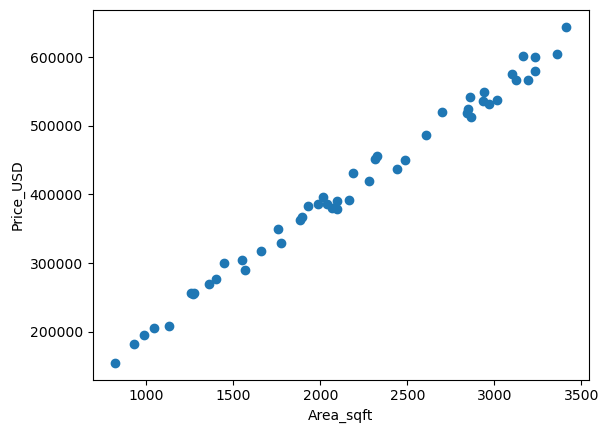

In [4]:
# scatterplot
plt.scatter(df['Area_sqft'] , df['Price_USD'])
plt.xlabel('Area_sqft')
plt.ylabel('Price_USD')
plt.show()

In [5]:
# correlation
df.corr()

,Area_sqft,Price_USD
Area_sqft,1.000000,0.995287
Price_USD,0.995287,1.000000


In [6]:
import seaborn as sns
sns.pairplot(df)

In [7]:
# indepenant and departandent fature
X = df[['Area_sqft']]
y = df['Price_USD']


In [8]:
## Train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.50,random_state=42)

In [9]:
#standardardization

In [10]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train =scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:
## Apply Linear Regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)

regression.fit(X_train,y_train)
print('Cofficient or slope:',regression.coef_)
print('Intercept',regression.intercept_)


Cofficient or slope: [134760.51949449]
Intercept 426081.16


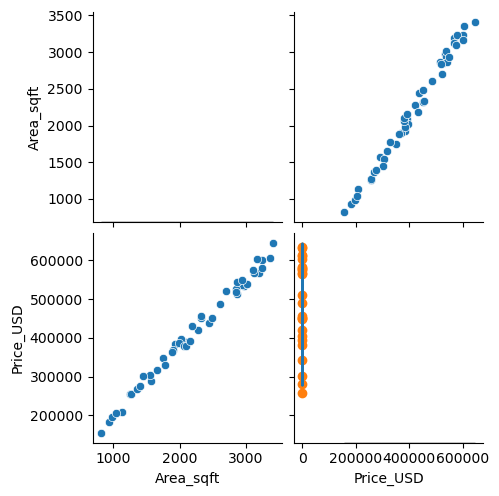

In [12]:
## Plot Best fit line acurding
plt.scatter(X_train, y_train)
plt.plot(X_train,regression.predict(X_train))
plt.show()


In [13]:
y_pred = regression.predict(X_test)

In [14]:
## Performance Metrices
from sklearn.metrics import mean_absolute_error ,mean_squared_error
mse = mean_squared_error(y_test,y_pred)
maf = mean_absolute_error(y_test,y_pred)
rsme=np.sqrt(mse)

In [15]:
#print all statements
print(f'Mean squared error: {mse}\n mean absolute error: {maf}\n RSME: {rsme}')

Mean squared error: 141567833.84023187
 mean absolute error: 9914.116050156976
 RSME: 11898.228180709591


In [16]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)

In [17]:
#adjested_R2
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.9900171628233941

In [18]:
## ols line
import statsmodels.api as sn
model = sn.OLS(X_train,y_train).fit()
predic = model.predict(X_train)
print(model.summary())


                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.091
Model:                            OLS   Adj. R-squared (uncentered):              0.053
Method:                 Least Squares   F-statistic:                              2.398
Date:                Sat, 04 Oct 2025   Prob (F-statistic):                       0.135
Time:                        12:13:21   Log-Likelihood:                         -34.283
No. Observations:                  25   AIC:                                      70.57
Df Residuals:                      24   BIC:                                      71.78
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [19]:
## prediction of new data
regression.predict(scaler.transform([[2024]]))

d:\test\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([384279.2069821])